# **Libraries that has been used**

In [6]:
!pip install catboost

In [7]:
!pip install lightgbm

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn import tree
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
import time
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score,mean_squared_error,precision_score,recall_score,f1_score,confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.svm import SVC

# **Discover the dataset**

In [9]:
data_set=pd.read_csv('online_shoppers_intention.csv')
data_set.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [10]:
data_set.shape

(12330, 18)

In [11]:
data_set.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [12]:
print("Total missing values:", data_set.isnull().sum().sum())


Total missing values: 0


In [13]:
print("Number of duplicate rows:", data_set.duplicated().sum())

Number of duplicate rows: 125


In [14]:
data_set.dtypes

,0
Administrative,int64
Administrative_Duration,float64
Informational,int64
Informational_Duration,float64
ProductRelated,int64
ProductRelated_Duration,float64
BounceRates,float64
ExitRates,float64
PageValues,float64
SpecialDay,float64


In [15]:
data_set["VisitorType"].value_counts() # 3 types of vistors

,count
VisitorType,
Returning_Visitor,10551
New_Visitor,1694
Other,85


In [16]:
#a session is a single visit to the website by a user

In [17]:
data_set["Month"].value_counts() # sessions per month (a3rf 2ih aktr 4ahr fi ziarat)

,count
Month,
May,3364
Nov,2998
Mar,1907
Dec,1727
Oct,549
Sep,448
Aug,433
Jul,432
June,288


In [18]:
data_set["Weekend"].value_counts() # there is a sessions in weekends more than weekdays

,count
Weekend,
False,9462
True,2868


In [19]:
data_set["Revenue"].value_counts() # the visit end with purchase or no purchase (here no purchase)

,count
Revenue,
False,10422
True,1908


# **Data Cleaning**

In [20]:
data_set = data_set.drop_duplicates() # I droped duplicated rows

In [21]:
print("Duplicates after cleaning:", data_set.duplicated().sum())

Duplicates after cleaning: 0


In [22]:
print("Shape after cleaning:", data_set.shape)

Shape after cleaning: (12205, 18)


In [23]:
x = data_set.drop("Revenue", axis=1)
y = data_set["Revenue"] # target ( purchase/ no purchase)

In [24]:
x.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12205 entries, 0 to 12329
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12205 non-null  int64  
 1   Administrative_Duration  12205 non-null  float64
 2   Informational            12205 non-null  int64  
 3   Informational_Duration   12205 non-null  float64
 4   ProductRelated           12205 non-null  int64  
 5   ProductRelated_Duration  12205 non-null  float64
 6   BounceRates              12205 non-null  float64
 7   ExitRates                12205 non-null  float64
 8   PageValues               12205 non-null  float64
 9   SpecialDay               12205 non-null  float64
 10  Month                    12205 non-null  object 
 11  OperatingSystems         12205 non-null  int64  
 12  Browser                  12205 non-null  int64  
 13  Region                   12205 non-null  int64  
 14  TrafficType              12

# **Data Preprocessing**



In [25]:
#encoding
encoder = OrdinalEncoder()
x[["Month", "VisitorType"]] = encoder.fit_transform(x[["Month", "VisitorType"]])

In [26]:
x.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12205 entries, 0 to 12329
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12205 non-null  int64  
 1   Administrative_Duration  12205 non-null  float64
 2   Informational            12205 non-null  int64  
 3   Informational_Duration   12205 non-null  float64
 4   ProductRelated           12205 non-null  int64  
 5   ProductRelated_Duration  12205 non-null  float64
 6   BounceRates              12205 non-null  float64
 7   ExitRates                12205 non-null  float64
 8   PageValues               12205 non-null  float64
 9   SpecialDay               12205 non-null  float64
 10  Month                    12205 non-null  float64
 11  OperatingSystems         12205 non-null  int64  
 12  Browser                  12205 non-null  int64  
 13  Region                   12205 non-null  int64  
 14  TrafficType              12

In [27]:
#spliting 80/20
x_train, x_test, y_train, y_test = train_test_split( x,y,test_size=0.2, random_state=42 )

In [28]:
x_train_scale_copy = x_train.copy()
x_test_scale_copy = x_test.copy()

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train_scale_copy)
x_test_scaled= scaler.transform(x_test_scale_copy)

# **Exploratory Data Analysis - EDA**

In [29]:
(x_train["ProductRelated"] == 0).mean() * 100 # Check how often visitors view zero product-related pages

np.float64(0.2765260139287178)

In [30]:
x_train["ProductRelated"].groupby(y_train).mean()# Compare average product-page visits between purchasing and non-purchasing sessions

,ProductRelated
Revenue,
False,29.068386
True,48.221216


In [31]:
x_train["ProductRelated_Duration"].groupby(y_train).mean()# Compare the average time spent on product-related pages

,ProductRelated_Duration
Revenue,
False,1076.262132
True,1877.520103


In [32]:
data_set["Revenue"].value_counts()

,count
Revenue,
False,10297
True,1908


In [33]:
data_set.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000
mean,2.338878,81.646331,0.508726,34.825454,32.045637,1206.982457,0.020370,0.041466,5.949574,0.061942,2.124211,2.357804,3.153298,4.073904
std,3.330436,177.491845,1.275617,141.424807,44.593649,1919.601400,0.045255,0.046163,18.653671,0.199666,0.906823,1.710114,2.402340,4.016654
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,8.000000,193.000000,0.000000,0.014231,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,9.000000,0.000000,0.000000,18.000000,608.942857,0.002899,0.025000,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,94.700000,0.000000,0.000000,38.000000,1477.154762,0.016667,0.048529,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


In [34]:
numeric_data = data_set.select_dtypes(include='number')
data_set_corr = numeric_data.corr().abs().round(2)
data_set_corr

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
Administrative,1.00,0.60,0.38,0.25,0.43,0.37,0.21,0.31,0.10,0.10,0.01,0.03,0.01,0.03
Administrative_Duration,0.60,1.00,0.30,0.24,0.29,0.35,0.14,0.20,0.07,0.07,0.01,0.02,0.01,0.01
Informational,0.38,0.30,1.00,0.62,0.37,0.39,0.11,0.16,0.05,0.05,0.01,0.04,0.03,0.04
Informational_Duration,0.25,0.24,0.62,1.00,0.28,0.35,0.07,0.10,0.03,0.03,0.01,0.02,0.03,0.03
ProductRelated,0.43,0.29,0.37,0.28,1.00,0.86,0.19,0.29,0.05,0.03,0.00,0.01,0.04,0.04
ProductRelated_Duration,0.37,0.35,0.39,0.35,0.86,1.00,0.17,0.25,0.05,0.04,0.00,0.01,0.03,0.04
BounceRates,0.21,0.14,0.11,0.07,0.19,0.17,1.00,0.90,0.12,0.09,0.03,0.02,0.00,0.09
ExitRates,0.31,0.20,0.16,0.10,0.29,0.25,0.90,1.00,0.17,0.12,0.02,0.00,0.00,0.09
PageValues,0.10,0.07,0.05,0.03,0.05,0.05,0.12,0.17,1.00,0.06,0.02,0.05,0.01,0.01
SpecialDay,0.10,0.07,0.05,0.03,0.03,0.04,0.09,0.12,0.06,1.00,0.01,0.00,0.02,0.05


In [35]:
#correlation between the target and the features
features_select=data_set_corr[data_set_corr['PageValues']>=0.01].index
features_select

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType'],
      dtype='object')

In [36]:
x_train["PageValues"].groupby(y_train).mean()

,PageValues
Revenue,
False,2.033178
True,27.652923


In [37]:
x_train["BounceRates"].groupby(y_train).mean()

,BounceRates
Revenue,
False,0.023171
True,0.005077


In [38]:
x_train["ExitRates"].groupby(y_train).mean()

,ExitRates
Revenue,
False,0.045485
True,0.019568


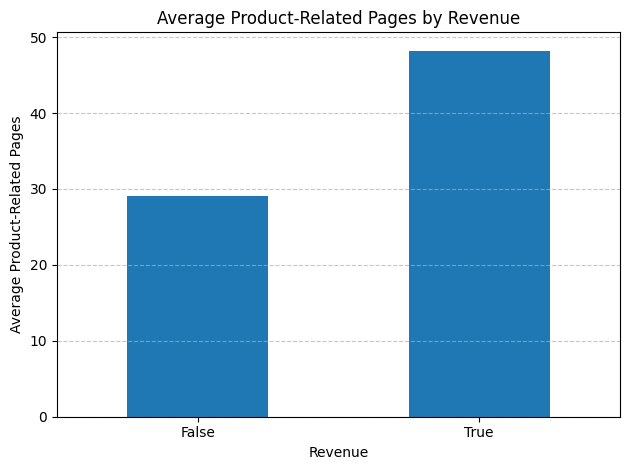

In [39]:
avg_product = x_train.groupby(y_train)["ProductRelated"].mean()

avg_product.plot(kind="bar")

plt.title("Average Product-Related Pages by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Average Product-Related Pages")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

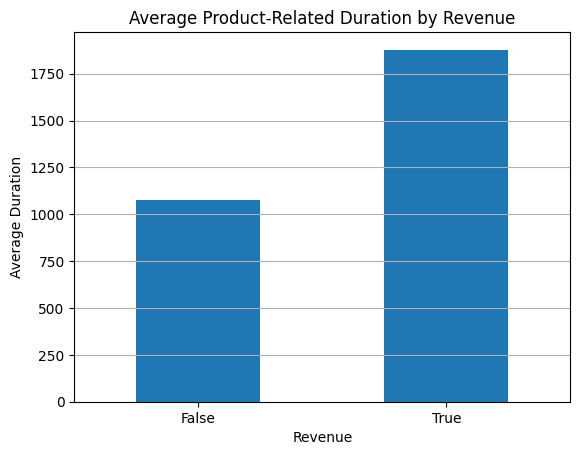

In [40]:
avg_duration = x_train.groupby(y_train)["ProductRelated_Duration"].mean()

avg_duration.plot(kind="bar")

plt.title("Average Product-Related Duration by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Average Duration")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

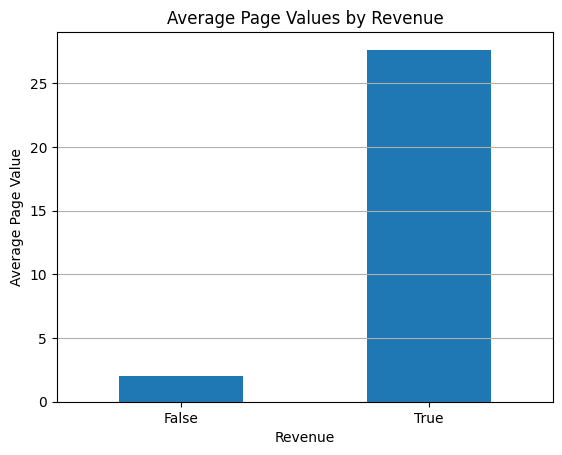

In [41]:
avg_page_values = x_train.groupby(y_train)["PageValues"].mean()

avg_page_values.plot(kind="bar")

plt.title("Average Page Values by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Average Page Value")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

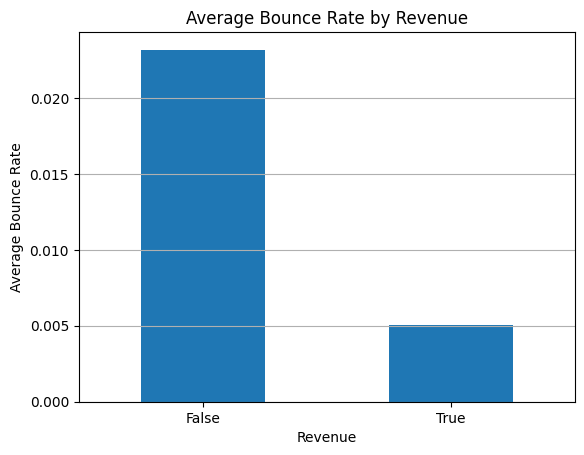

In [42]:
avg_bounce = x_train.groupby(y_train)["BounceRates"].mean()

avg_bounce.plot(kind="bar")

plt.title("Average Bounce Rate by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Average Bounce Rate")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

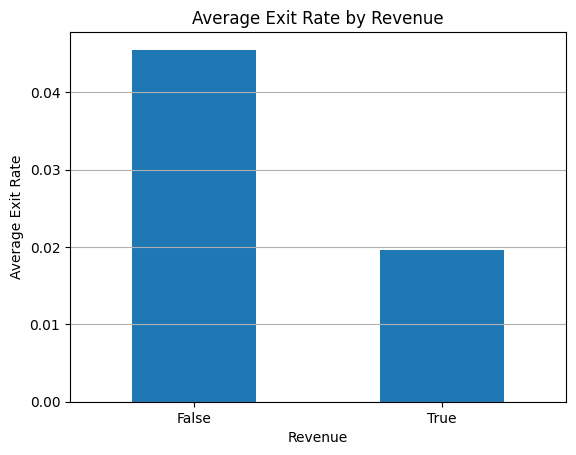

In [43]:
avg_exit = x_train.groupby(y_train)["ExitRates"].mean()

avg_exit.plot(kind="bar")

plt.title("Average Exit Rate by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Average Exit Rate")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

In [44]:
data_set.groupby("VisitorType")["Revenue"].mean() * 100

,Revenue
VisitorType,
New_Visitor,24.926167
Other,19.753086
Returning_Visitor,14.092609


In [45]:
data_set.groupby("Weekend")["Revenue"].mean() * 100

,Revenue
Weekend,
False,15.075968
True,17.453655


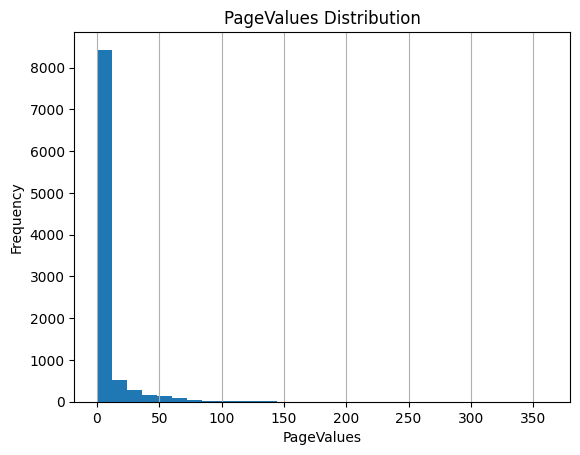

In [46]:
x_train["PageValues"].hist(bins=30)

plt.title("PageValues Distribution")
plt.xlabel("PageValues")
plt.ylabel("Frequency")
plt.grid(axis="y")
plt.show()

In [47]:
corr = x_train.corr(numeric_only=True)

corr

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend
Administrative,1.000000,0.608376,0.380541,0.264204,0.427415,0.390516,-0.211863,-0.307630,0.091038,-0.095994,0.046360,-0.005694,-0.025676,-0.005821,-0.032637,-0.020668,0.022914
Administrative_Duration,0.608376,1.000000,0.306099,0.224397,0.283605,0.333227,-0.136722,-0.200861,0.065782,-0.073461,0.035918,-0.010893,-0.019687,-0.008797,-0.006046,-0.019262,0.011947
Informational,0.380541,0.306099,1.000000,0.631604,0.380735,0.398280,-0.108754,-0.160381,0.040845,-0.046946,0.017704,-0.009591,-0.042276,-0.030489,-0.032557,0.055143,0.037831
Informational_Duration,0.264204,0.224397,0.631604,1.000000,0.274245,0.315850,-0.069925,-0.104540,0.025243,-0.032537,0.007878,-0.006615,-0.024116,-0.028954,-0.027432,0.040049,0.023336
ProductRelated,0.427415,0.283605,0.380735,0.274245,1.000000,0.880388,-0.193075,-0.285326,0.053616,-0.023829,0.073959,0.001080,-0.010870,-0.042525,-0.045732,0.126670,0.017359
ProductRelated_Duration,0.390516,0.333227,0.398280,0.315850,0.880388,1.000000,-0.178378,-0.252743,0.052858,-0.037495,0.073999,0.002739,-0.005540,-0.036115,-0.037899,0.121135,0.013044
BounceRates,-0.211863,-0.136722,-0.108754,-0.069925,-0.193075,-0.178378,1.000000,0.901311,-0.116226,0.085363,-0.017569,0.029232,-0.014871,0.002661,0.083443,0.131995,-0.039012
ExitRates,-0.307630,-0.200861,-0.160381,-0.104540,-0.285326,-0.252743,0.901311,1.000000,-0.174398,0.111596,-0.032928,0.015710,-0.001055,-0.001174,0.081133,0.178053,-0.056348
PageValues,0.091038,0.065782,0.040845,0.025243,0.053616,0.052858,-0.116226,-0.174398,1.000000,-0.063932,0.022373,0.013809,0.042189,0.011913,0.012004,-0.103602,0.009550
SpecialDay,-0.095994,-0.073461,-0.046946,-0.032537,-0.023829,-0.037495,0.085363,0.111596,-0.063932,1.000000,0.076351,0.012172,0.002394,-0.009740,0.040525,0.085969,-0.015833


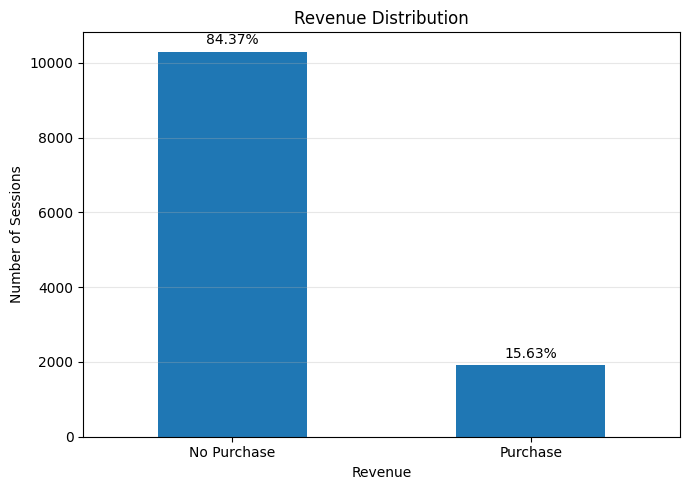

In [48]:
revenue_counts = data_set["Revenue"].value_counts()
percentages = data_set["Revenue"].value_counts(normalize=True) * 100

ax = revenue_counts.plot(
    kind="bar",
    figsize=(7, 5),
    title="Revenue Distribution",)

plt.xlabel("Revenue")
plt.ylabel("Number of Sessions")
plt.xticks(
    [0, 1],
    ["No Purchase", "Purchase"],rotation=0)

plt.grid(axis="y", alpha=0.3)

ax.bar_label( ax.containers[0],labels=[f"{x:.2f}%" for x in percentages],padding=3)

plt.tight_layout()
plt.show()

# 📌**Model Building & Training**

# **Logistic Regression**

In [49]:
logistic_model=LogisticRegression(max_iter=1000,random_state=42,class_weight='balanced')
logistic_model.fit(x_train_scaled,y_train)

y_train_pred_log = logistic_model.predict(x_train_scaled)
y_test_pred_log=logistic_model.predict(x_test_scaled)


In [50]:
print("train_accuracy_log",accuracy_score (y_train, y_train_pred_log))
print("test_accuracy_log",accuracy_score(y_test, y_test_pred_log))
print("train_precision_log" , precision_score(y_train,y_train_pred_log))
print("test_precision_log" , precision_score( y_test,y_test_pred_log))
print("train_recall_log ", recall_score(y_train, y_train_pred_log))
print("test_recall_log" , recall_score( y_test, y_test_pred_log))
print("train_f1_log" , f1_score(y_train,y_train_pred_log))
print("test_f1_log" , f1_score(y_test, y_test_pred_log))



train_accuracy_log 0.8725931995083982
test_accuracy_log 0.8680868496517821
train_precision_log 0.5743110236220472
test_precision_log 0.5423728813559322
train_recall_log  0.7548512289780077
test_recall_log 0.7071823204419889
train_f1_log 0.6523197316936836
test_f1_log 0.6139088729016786


# **CatBoost**

In [51]:
#decode the columns for catboost best experience
x_train_cat = x_train.copy()
x_test_cat = x_test.copy()
x_all_cat = x.copy()

x_train_cat[["Month", "VisitorType"]] = data_set.loc[x_train.index, ["Month", "VisitorType"]]
x_test_cat[["Month", "VisitorType"]] = data_set.loc[x_test.index, ["Month", "VisitorType"]]
x_all_cat[["Month", "VisitorType"]] = data_set.loc[x.index, ["Month", "VisitorType"]]


In [52]:
cat_features = ["Month", "VisitorType"]

cat_model=CatBoostClassifier(iterations=300, learning_rate=0.05,depth=3,random_state=42,verbose= False,auto_class_weights='Balanced')

cat_model.fit(x_train_cat, y_train, cat_features=cat_features)

y_train_pred_cat = cat_model.predict(x_train_cat)

start_time_test = time.time()
y_test_pred_cat = cat_model.predict(x_test_cat)
end_time_test = time.time()
final_test=end_time_test-start_time_test
print("time_pred_test:",final_test)

start_time_all = time.time()
y_all_pred_cat = cat_model.predict(x_all_cat)
end_time_all = time.time()
final_all_X=end_time_all-start_time_all
print("time_pred_X:",final_all_X)


time_pred_test: 0.01705145835876465
time_pred_X: 0.04400014877319336


In [53]:
print("train_accuracy_cat",accuracy_score (y_train, y_train_pred_cat))
print("test_accuracy_cat",accuracy_score(y_test, y_test_pred_cat))
print("train_precision_cat" , precision_score(y_train,y_train_pred_cat))
print("test_precision_cat" , precision_score( y_test,y_test_pred_cat))
print("train_recall_cat", recall_score(y_train, y_train_pred_cat))
print("test_recall_cat" , recall_score( y_test, y_test_pred_cat))
print("train_f1_cat" , f1_score(y_train,y_train_pred_cat))
print("test_f1_cat" , f1_score(y_test, y_test_pred_cat))

train_accuracy_cat 0.8737197869725523
test_accuracy_cat 0.8705448586644817
train_precision_cat 0.5670810115730819
test_precision_cat 0.5422794117647058
train_recall_cat 0.8557567917205692
test_recall_cat 0.8149171270718232
train_f1_cat 0.6821345707656613
test_f1_cat 0.6512141280353201


# **LightGBM**

In [54]:
x_train_lgb = x_train.copy()
x_test_lgb = x_test.copy()

category_features = ["Month", "VisitorType"]

x_train_lgb[category_features] = x_train_lgb[category_features].astype("category")
x_test_lgb[category_features] = x_test_lgb[category_features].astype("category")

In [55]:
lgb_model = LGBMClassifier(n_estimators=300, learning_rate=0.05, max_depth=5 , class_weight='balanced' , verbose=-1)

lgb_model.fit(x_train_lgb, y_train)

y_train_pred_lgb = lgb_model.predict(x_train_lgb)
y_test_pred_lgb = lgb_model.predict(x_test_lgb)

In [56]:
print("train_accuracy_lgb",accuracy_score (y_train, y_train_pred_lgb))
print("test_accuracy_lgb",accuracy_score(y_test, y_test_pred_lgb))
print("train_precision_lgb" , precision_score(y_train,y_train_pred_lgb))
print("test_precision_lgb" , precision_score( y_test,y_test_pred_lgb))
print("train_recall_lgb", recall_score(y_train, y_train_pred_lgb))
print("test_recall_lgb" , recall_score( y_test, y_test_pred_lgb))
print("train_f1_lgb" , f1_score(y_train,y_train_pred_lgb))
print("test_f1_lgb" , f1_score(y_test, y_test_pred_lgb))

train_accuracy_lgb 0.9201147070872593
test_accuracy_lgb 0.8738222040147481
train_precision_lgb 0.6768236380424746
test_precision_lgb 0.5544354838709677
train_recall_lgb 0.9482535575679172
test_recall_lgb 0.7596685082872928
train_f1_lgb 0.7898706896551724
test_f1_lgb 0.6410256410256411


# **XGboosting**

In [57]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb_model = XGBClassifier(random_state=42,n_jobs=-1,scale_pos_weight=scale_pos_weight)
param_grid_xgb = {'n_estimators': [100, 300],'learning_rate': [0.05, 0.1],'max_depth': [3, 6]}
grid_xgb = GridSearchCV(estimator=xgb_model, param_grid=param_grid_xgb, cv=5,scoring='f1',n_jobs=-1)
grid_xgb.fit(x_train, y_train)
print("Best Parameters:", grid_xgb.best_params_)

Best Parameters: {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 300}


In [58]:
xgb_model = XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=6,random_state=42,n_jobs=-1,scale_pos_weight=scale_pos_weight)

start_time = time.time()
xgb_model.fit(x_train, y_train)
xgb_time = time.time() - start_time

y_pred_xgb = xgb_model.predict(x)
y_pred_xgb_test = xgb_model.predict(x_test)
y_pred_xgb_train = xgb_model.predict(x_train)

In [59]:
print('Accuracy Train:',accuracy_score(y_train, xgb_model.predict(x_train)) * 100)
print('Accuracy Test:',accuracy_score(y_test, xgb_model.predict(x_test)) * 100)
print('Precision:',precision_score(y_test, xgb_model.predict(x_test)) * 100)
print('Recall:',recall_score(y_test, xgb_model.predict(x_test)) * 100)
print('F1:',f1_score(y_test, xgb_model.predict(x_test)) * 100)
print('Time:', xgb_time)


Accuracy Train: 94.84842277755018
Accuracy Test: 87.58705448586645
Precision: 56.344086021505376
Recall: 72.37569060773481
F1: 63.361547762998796
Time: 10.07223629951477


# **Decission tree entropy**


In [60]:
#grid search to pick best max_depth without overfitting or underfitting

model_dtc_grid=DecisionTreeClassifier(criterion='entropy', min_samples_split=2, min_samples_leaf=1 , random_state= 42)

grid_param = {'max_depth': [3, 5, 7, 9, 12, 15]}
grid_search = GridSearchCV(estimator=model_dtc_grid, param_grid=grid_param, cv=5)
grid_search.fit(x,y)

print("Best max_depth:", grid_search.best_params_)

Best max_depth: {'max_depth': 5}


In [61]:
model_dtc=DecisionTreeClassifier(criterion='entropy', max_depth=5 , min_samples_split=2, min_samples_leaf=1 ,class_weight='balanced', random_state=42)

start_time=time.time()
model_dtc.fit(x,y)
time_dtc = time.time() - start_time

In [62]:
start_time=time.time()
y_pred_dtc= model_dtc.predict(x)
time_dtc_pred = time.time() - start_time

y_pred_dtc
print("pred time" , time_dtc_pred)

pred time 0.01722550392150879


In [63]:
start_time=time.time()
y_pred_dtc_test = model_dtc.predict(x_test)
time_dtc_pred_test = time.time() - start_time

y_pred_dtc_train = model_dtc.predict(x_train)

print("pred time test" , time_dtc_pred_test)

pred time test 0.01774907112121582


In [64]:

print("train_accuracy_dtc=" ,  accuracy_score (y_train, y_pred_dtc_train))
print("test_accuracy_dtc="  ,accuracy_score(y_test, y_pred_dtc_test))
print("train_precision_dtc =", precision_score(y_train,y_pred_dtc_train))
print("test_precision_dtc = ", precision_score( y_test,y_pred_dtc_test))
print("train_recall_dtc =" , recall_score(y_train, y_pred_dtc_train))
print("test_recall_dtc =" , recall_score( y_test,y_pred_dtc_test))
print("train_f1_dtc =" , f1_score(y_train,y_pred_dtc_train))
print("test_f1_dtc =", f1_score(y_test,y_pred_dtc_test))
print("time_dtc=",time_dtc)

train_accuracy_dtc= 0.8584596476853749
test_accuracy_dtc= 0.8541581319131504
train_precision_dtc = 0.5324367088607594
test_precision_dtc =  0.5049180327868853
train_recall_dtc = 0.8706338939197931
test_recall_dtc = 0.850828729281768
train_f1_dtc = 0.6607756504663721
test_f1_dtc = 0.6337448559670782
time_dtc= 0.21983885765075684


In [65]:
(sum(y==y_pred_dtc)/len(y))*100

85.759934453093

In [66]:
confusion_matrix(y,y_pred_dtc)

array([[8813, 1484],
       [ 254, 1654]])

[Text(0.4676724137931034, 0.9166666666666666, 'node #0\nx[8] <= 0.053\nentropy = 1.0\nsamples = 12205\nvalue = [6102.5, 6102.5]'),
 Text(0.21120689655172414, 0.75, 'node #1\nx[10] <= 6.5\nentropy = 0.68\nsamples = 9476\nvalue = [5396.656, 1183.399]'),
 Text(0.3394396551724138, 0.8333333333333333, 'True  '),
 Text(0.11206896551724138, 0.5833333333333334, 'node #2\nx[10] <= 4.5\nentropy = 0.342\nsamples = 6575\nvalue = [3848.066, 262.267]'),
 Text(0.06896551724137931, 0.4166666666666667, 'node #3\nx[1] <= 1.0\nentropy = 0.632\nsamples = 2423\nvalue = [1387.39, 262.267]'),
 Text(0.034482758620689655, 0.25, 'node #4\nx[5] <= 172.104\nentropy = 0.317\nsamples = 1342\nvalue = [786.444, 47.976]'),
 Text(0.017241379310344827, 0.08333333333333333, 'node #5\nentropy = 0.0\nsamples = 547\nvalue = [324.179, 0.0]'),
 Text(0.05172413793103448, 0.08333333333333333, 'node #6\nentropy = 0.45\nsamples = 795\nvalue = [462.266, 47.976]'),
 Text(0.10344827586206896, 0.25, 'node #7\nx[5] <= 166.353\nentropy

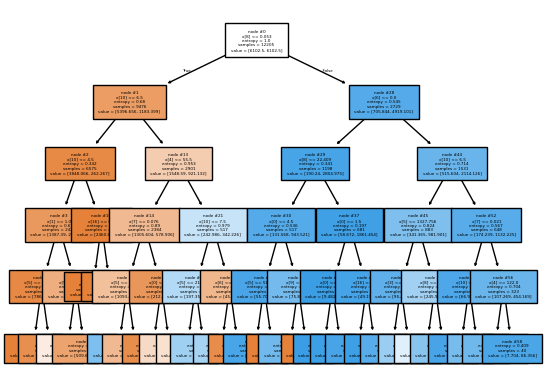

In [67]:
import matplotlib.pyplot as plt
tree.plot_tree(model_dtc, filled=True, node_ids=True, fontsize=3)

# **Decission tree gini**

In [68]:
dtc_gini= DecisionTreeClassifier(criterion='gini' , max_depth=5 , min_samples_split=2 , min_samples_leaf=1 , class_weight='balanced', random_state=42) #same max depth as entropy grid

start_time=time.time()
dtc_gini.fit(x_train, y_train)
time_gini = time.time() - start_time

y_pred_gini = dtc_gini.predict(x)
y_pred_test_gini = dtc_gini.predict(x_test)
y_pred_train_gini = dtc_gini.predict(x_train)

y_pred_gini

array([False, False, False, ..., False, False,  True])

In [69]:
print("train_accuracy_gini=" ,  accuracy_score (y_train, y_pred_train_gini))
print("test_accuracy_gini="  ,accuracy_score(y_test, y_pred_test_gini))


print("train_precision_gini =", precision_score(y_train,y_pred_train_gini))
print("test_precision_gini = ", precision_score( y_test,y_pred_test_gini))


print("train_recall_gini =" , recall_score(y_train, y_pred_train_gini))
print("test_recall_gini =" , recall_score( y_test,y_pred_test_gini))

print("train_f1_gini =" , f1_score(y_train,y_pred_train_gini))
print("test_f1_gini =", f1_score(y_test,y_pred_test_gini))

print("time_gini=",time_gini)

train_accuracy_gini= 0.8690086030315445
test_accuracy_gini= 0.8541581319131504
train_precision_gini = 0.555741127348643
test_precision_gini =  0.5052264808362369
train_recall_gini = 0.8609314359637775
test_recall_gini = 0.8011049723756906
train_f1_gini = 0.6754630804364374
test_f1_gini = 0.6196581196581197
time_gini= 0.0752875804901123


[Text(0.4675925925925926, 0.9166666666666666, 'node #0\nx[8] <= 0.053\ngini = 0.5\nsamples = 9764\nvalue = [4882.0, 4882.0]'),
 Text(0.22685185185185186, 0.75, 'node #1\nx[10] <= 6.5\ngini = 0.289\nsamples = 7559\nvalue = [4318.235, 915.77]'),
 Text(0.3472222222222222, 0.8333333333333333, 'True  '),
 Text(0.12037037037037036, 0.5833333333333334, 'node #2\nx[10] <= 4.5\ngini = 0.116\nsamples = 5227\nvalue = [3067.141, 202.101]'),
 Text(0.07407407407407407, 0.4166666666666667, 'node #3\nx[1] <= 1.0\ngini = 0.26\nsamples = 1938\nvalue = [1113.272, 202.101]'),
 Text(0.037037037037037035, 0.25, 'node #4\nx[15] <= 0.5\ngini = 0.101\nsamples = 1047\nvalue = [615.448, 34.736]'),
 Text(0.018518518518518517, 0.08333333333333333, 'node #5\ngini = 0.37\nsamples = 104\nvalue = [58.218, 18.947]'),
 Text(0.05555555555555555, 0.08333333333333333, 'node #6\ngini = 0.054\nsamples = 943\nvalue = [557.23, 15.789]'),
 Text(0.1111111111111111, 0.25, 'node #7\nx[5] <= 166.353\ngini = 0.377\nsamples = 891\nva

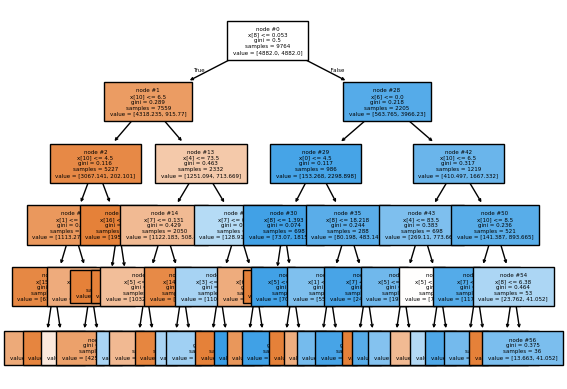

In [70]:
import matplotlib.pyplot as plt
tree.plot_tree(dtc_gini, filled=True, node_ids=True, fontsize=4)

In [71]:
confusion_matrix(y,y_pred_gini)

array([[8949, 1348],
       [ 287, 1621]])

# **Random forest**

In [72]:
#grid for best nums without overfitting or underfitting

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf_model = RandomForestClassifier(random_state=42)

grid_rf = {'n_estimators': [100],'max_depth': [5, 10, 15], 'min_samples_split': [10, 20], 'min_samples_leaf': [5, 10] }
grid_search_rf = GridSearchCV(estimator=rf_model, param_grid=grid_rf, cv=5)
grid_search_rf.fit(x_train, y_train)

print("Best n_estimators:", grid_search_rf.best_params_)


'\nfrom sklearn.ensemble import RandomForestClassifier\nfrom sklearn.model_selection import GridSearchCV\n\nrf_model = RandomForestClassifier(random_state=42)\n\ngrid_rf = {\'n_estimators\': [100],\'max_depth\': [5, 10, 15], \'min_samples_split\': [10, 20], \'min_samples_leaf\': [5, 10] }\ngrid_search_rf = GridSearchCV(estimator=rf_model, param_grid=grid_rf, cv=5)\ngrid_search_rf.fit(x_train_encoded, y_train)\n\nprint("Best n_estimators:", grid_search_rf.best_params_)\n'

In [73]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100 , max_depth=15 ,class_weight='balanced' , min_samples_split=20 , min_samples_leaf=5 , random_state=42)

start_time=time.time()
rf_model.fit(x_train, y_train)
time_rf = time.time() - start_time

y_pred_rf = rf_model.predict(x)
y_pred_test_rf = rf_model.predict(x_test)
y_pred_train_rf = rf_model.predict(x_train)

y_pred_rf

array([False, False, False, ..., False, False, False])

In [74]:
print("train_accuracy_rf=" ,  accuracy_score (y_train, y_pred_train_rf))
print("test_accuracy_rf="  ,accuracy_score(y_test, y_pred_test_rf))


print("train_precision_rf =", precision_score(y_train,y_pred_train_rf))
print("test_precision_rf = ", precision_score(y_test,y_pred_test_rf))


print("train_recall_rf =" , recall_score(y_train, y_pred_train_rf))
print("test_recall_rf =" , recall_score(y_test,y_pred_test_rf))

print("train_f1_rf =" , f1_score(y_train,y_pred_train_rf))
print("test_f1_rf =", f1_score(y_test,y_pred_test_rf))

print("time_rf=",time_rf)

train_accuracy_rf= 0.911716509627202
test_accuracy_rf= 0.8762802130274477
train_precision_rf = 0.6631679389312977
test_precision_rf =  0.5617283950617284
train_recall_rf = 0.8990944372574385
test_recall_rf = 0.7541436464088398
train_f1_rf = 0.7633168588687534
test_f1_rf = 0.6438679245283019
time_rf= 1.6530656814575195


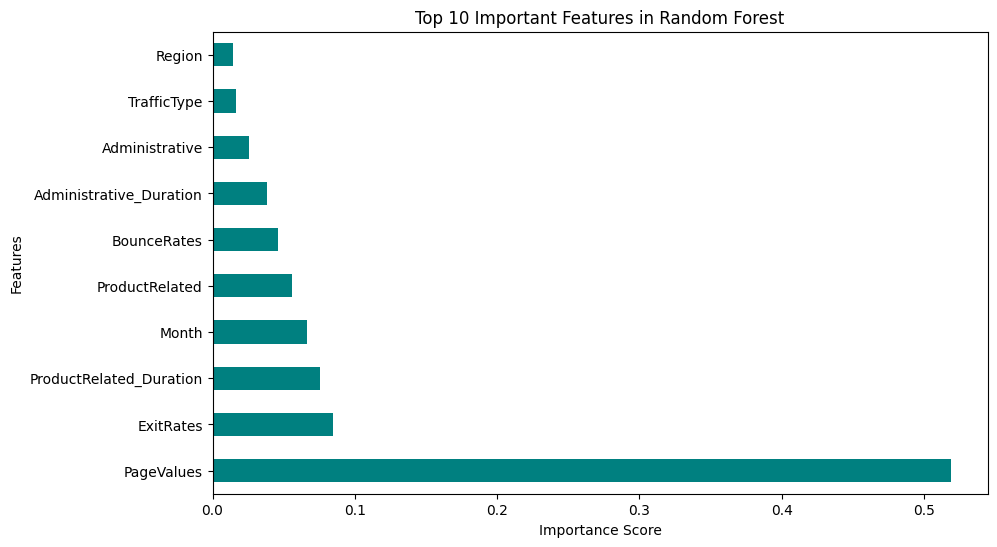

In [75]:


importances = rf_model.feature_importances_
columns = x_train.columns
feat_importances = pd.Series(importances, index=columns)

plt.figure(figsize=(10, 6))
feat_importances.nlargest(10).plot(kind='barh', color='teal')
plt.title('Top 10 Important Features in Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Features')

plt.show()

# **SVM**

In [76]:
svm = SVC(class_weight='balanced', random_state=42)
param_grid_svm ={'C': [0.1, 1, 10, 100],'kernel': ['rbf'],'gamma': ['scale']}
grid_search_svm = GridSearchCV(estimator=svm , param_grid=param_grid_svm , cv=3 , scoring='f1', n_jobs=-1)
grid_search_svm.fit(x_train, y_train)
grid_search_svm.best_params_

{'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}

In [77]:
svm = SVC(class_weight='balanced', random_state=42 , C=100 , gamma='scale' , kernel='rbf')

svm.fit(x_train, y_train)

y_train_pred_svm = svm.predict(x_train)
y_test_pred_svm = svm.predict(x_test)

print('Accuracy Train:', accuracy_score(y_train, y_train_pred_svm) * 100)
print('Accuracy Test:', accuracy_score(y_test, y_test_pred_svm) * 100)
print('Precision:', precision_score(y_test, y_test_pred_svm) * 100)
print('Recall:', recall_score(y_test, y_test_pred_svm) * 100)
print('F1:', f1_score(y_test, y_test_pred_svm) * 100)

Accuracy Train: 85.46702171241294
Accuracy Test: 85.4977468250717
Precision: 50.76923076923077
Recall: 72.92817679558011
F1: 59.863945578231295


# **Final results**

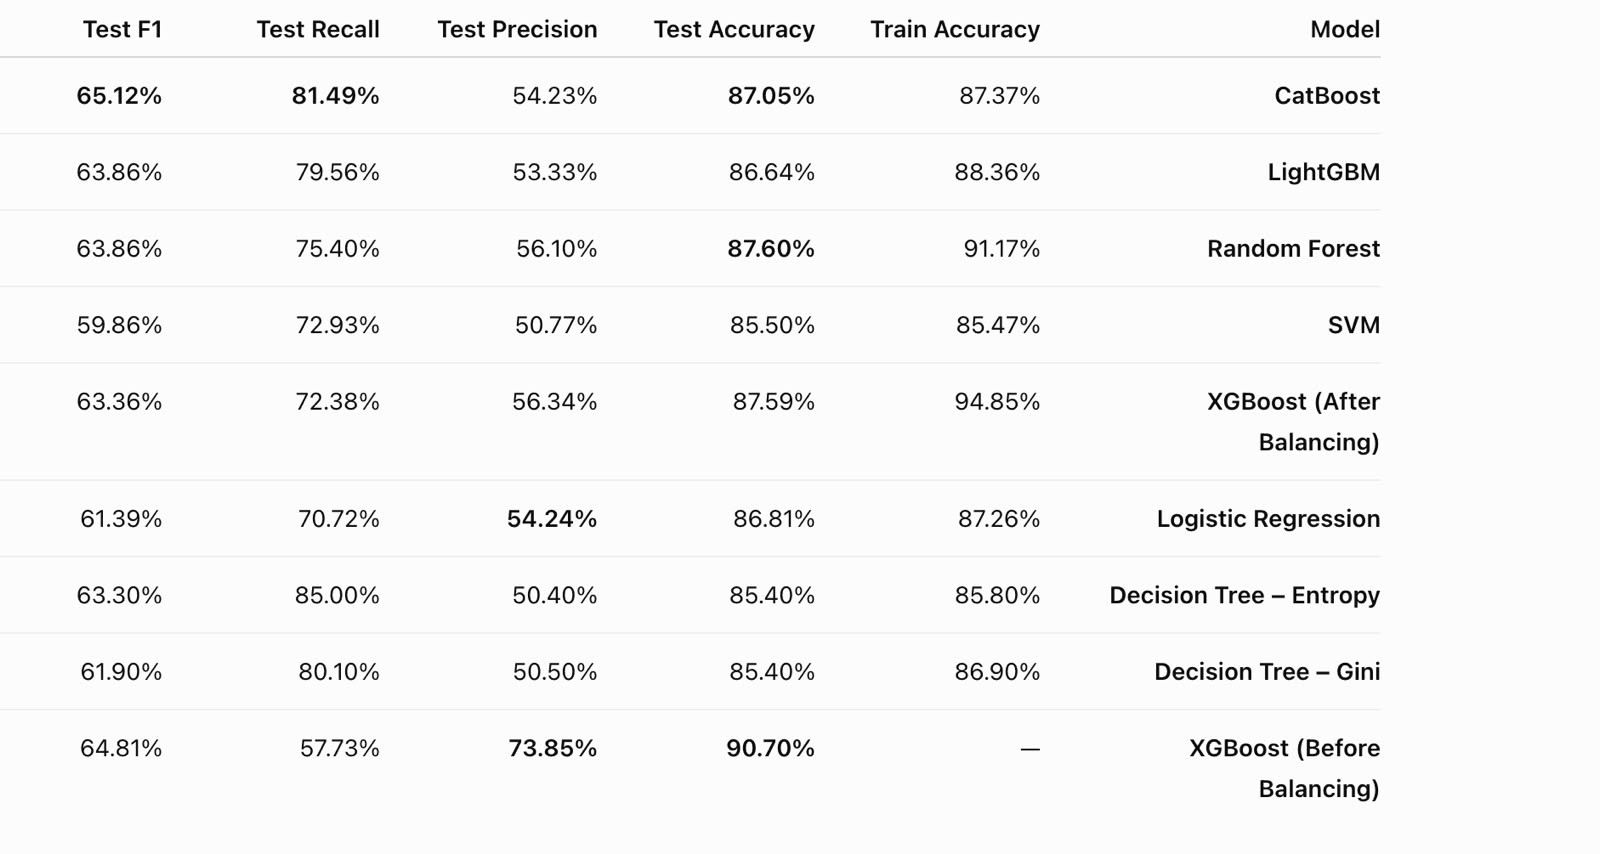

# **Files for Streamlit "deploy"**

In [78]:
import joblib
joblib.dump(model_dtc, 'decision_tree_model.pkl')


['decision_tree_model.pkl']

In [79]:
cat_model.save_model('catboost_model.cbm')

In [80]:
joblib.dump(encoder, 'encoder.pkl')

['encoder.pkl']